In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn import tree

In [2]:
data = pd.read_csv(r"G:\aarchi_eda\Datasets\EnglishSpam.csv" ,sep="\t",header=None)
data=data.rename(columns = {0:'label',1:'message'})
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

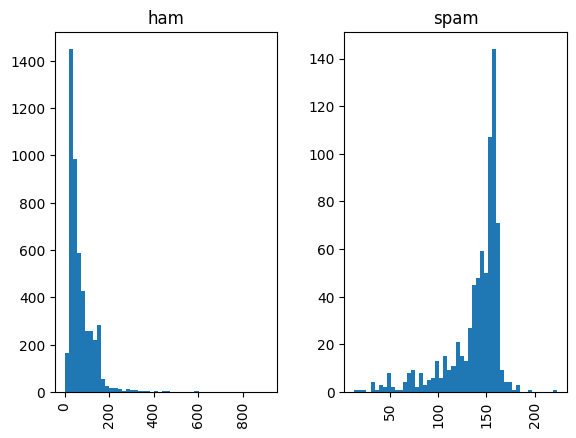

In [3]:
data['length'] = data['message'].map(lambda text: len(text))
data.hist(column='length', by='label', bins=50)

In [4]:
data['spam'] = data['label'].apply(lambda x: 1 if x == 'spam' else 0)
data

,label,message,length,spam
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,1
5568,ham,Will ü b going to esplanade fr home?,36,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,0
5570,ham,The guy did some bitching but I acted like i'd...,125,0


In [5]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(data.message, data.spam, test_size = 0.30)

In [6]:
x_train

5401    Babes I think I got ur brolly I left it in Eng...
116     As I entered my cabin my PA said, '' Happy B'd...
2133    Your B4U voucher w/c 27/03 is MARSMS. Log onto...
1314              How abt making some of the pics bigger?
3576    And do you have any one that can teach me how ...
                              ...                        
4469                           Much better now thanks lol
1277                                        Can do lor...
2025              U having lunch alone? I now so bored...
898     I'm used to it. I just hope my agents don't dr...
1013        I dunno they close oredi not... Ü v ma fan...
Name: message, Length: 3900, dtype: object

In [7]:
x_train.describe()

count                       3900
unique                      3687
top       Sorry, I'll call later
freq                          23
Name: message, dtype: object

In [8]:
# can also be used vectorizer instead of countvectorizer
cv = CountVectorizer()
x_train_count = cv.fit_transform(x_train.values)

In [9]:
x_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 52071 stored elements and shape (3900, 7217)>

In [10]:
x_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3900, 7217))

In [11]:
# train model
model = MultinomialNB()
model.fit(x_train_count, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
#test model
x_test_count = cv.transform(x_test)
model.score(x_test_count, y_test)

0.9838516746411483

In [13]:
predicted=model.predict(x_test_count)

In [14]:
predicted

array([0, 0, 0, ..., 1, 0, 0], shape=(1672,))

In [15]:
print(metrics.classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1440
           1       0.98      0.90      0.94       232

    accuracy                           0.98      1672
   macro avg       0.98      0.95      0.97      1672
weighted avg       0.98      0.98      0.98      1672



Confusion Matrix:
[[ 209   23]
 [   4 1436]]


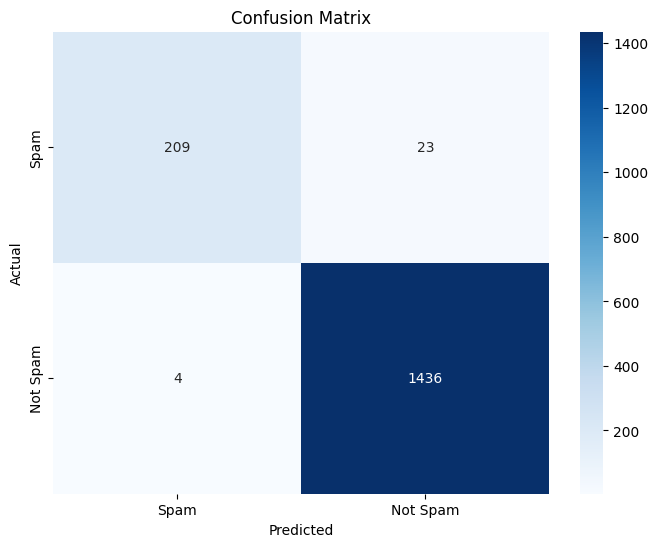

In [16]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, predicted, labels=[1, 0])

# Print confusion matrix
print("Confusion Matrix:")
print(cm)



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Spam', 'Not Spam'], yticklabels=['Spam', 'Not Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Test the Result with different email.

In [17]:
email_ham = ['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...']
email_ham_count = cv.transform(email_ham)
model.predict(email_ham_count)

array([0])

In [18]:
email_spam = ['Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&Cs apply 08452810075over18s']
email_spam_count = cv.transform(email_spam)
model.predict(email_spam_count)

array([1])

In [19]:
email_ham = ['hey wanna meet up for the game this tuesday?']
email_ham_count = cv.transform(email_ham)
model.predict(email_ham_count)

array([0])

In [20]:
email_spam = ['reward money click']
email_spam_count = cv.transform(email_spam)
model.predict(email_spam_count)

array([1])